In [25]:
import os
import numpy as np
import pandas as pd
from skimage.feature import hog
from PIL import Image
import matplotlib.pyplot as plt

# Based on the folder structure in your Kaggle screenshot
TRAIN_DIR = "/kaggle/input/datasets/khadejabk/cats-vs-dogs/catsvsdogs/train"

# Use a larger size so images are clearer
IMG_SIZE = (128, 128)

# Number of images per class
SAMPLE_SIZE = 200

print("Train directory:", TRAIN_DIR)
print("Folders:", os.listdir(TRAIN_DIR))

Train directory: /kaggle/input/datasets/khadejabk/cats-vs-dogs/catsvsdogs/train
Folders: ['dogs', 'cats']


In [16]:
def load_images(folder, label, n):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Take only n images
    files = files[:n]

    data = []
    labels = []

    for fname in files:
        img_path = os.path.join(folder, fname)

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(IMG_SIZE)

            data.append(np.array(img))
            labels.append(label)

        except Exception as e:
            print("Could not load:", fname, e)

    return data, labels


cat_imgs, cat_labels = load_images(
    os.path.join(TRAIN_DIR, "cats"),
    "cat",
    SAMPLE_SIZE
)

dog_imgs, dog_labels = load_images(
    os.path.join(TRAIN_DIR, "dogs"),
    "dog",
    SAMPLE_SIZE
)

# Combine cats and dogs
images = np.array(cat_imgs + dog_imgs)
true_labels = cat_labels + dog_labels

print("Images shape:", images.shape)
print("Number of labels:", len(true_labels))

Images shape: (400, 128, 128, 3)
Number of labels: 400


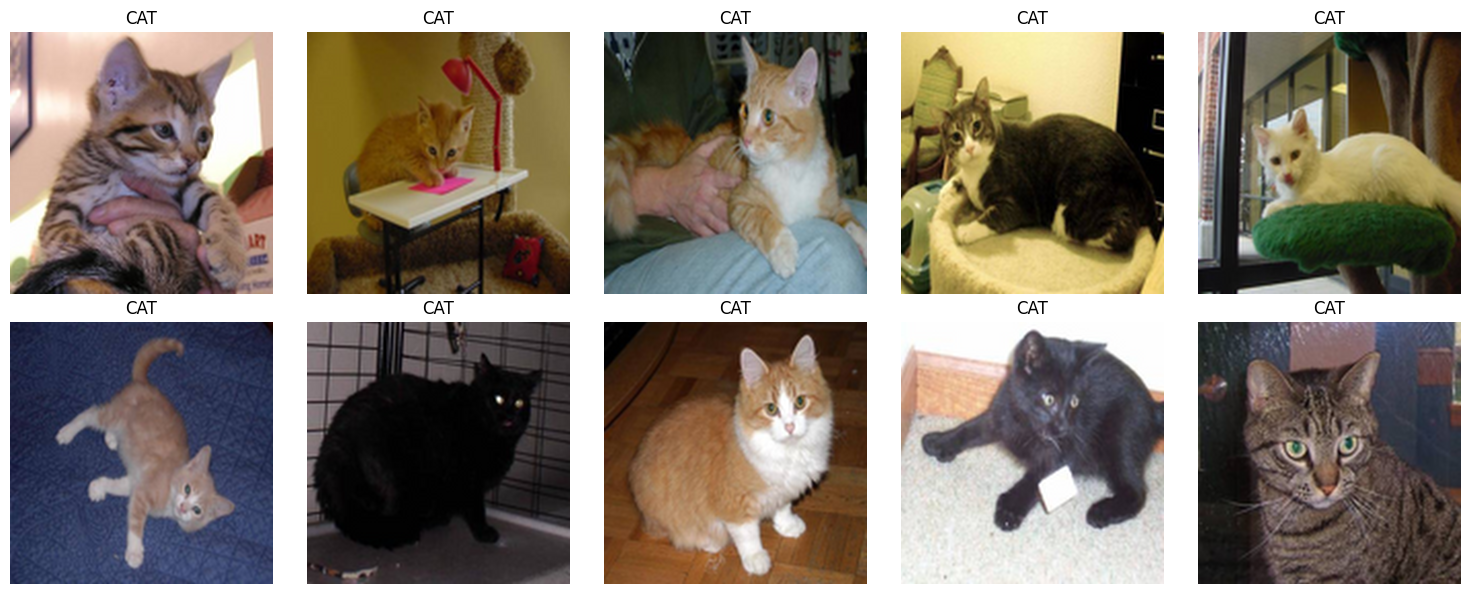

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], interpolation="lanczos")
    ax.set_title(true_labels[i].upper(), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
X = []

for img in images:
    gray = np.mean(img, axis=2)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    X.append(features)

X = np.array(X)

print("Feature shape:", X.shape)

Feature shape: (400, 8100)


In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [43]:
predicted_clusters = kmeans.predict(X)

print(pd.Series(predicted_clusters).value_counts())

1    238
0    162
Name: count, dtype: int64


In [44]:
comparison = pd.crosstab(
    predicted_clusters,
    true_labels
)

print(comparison)

col_0  cat  dog
row_0          
0       96   66
1      104  134


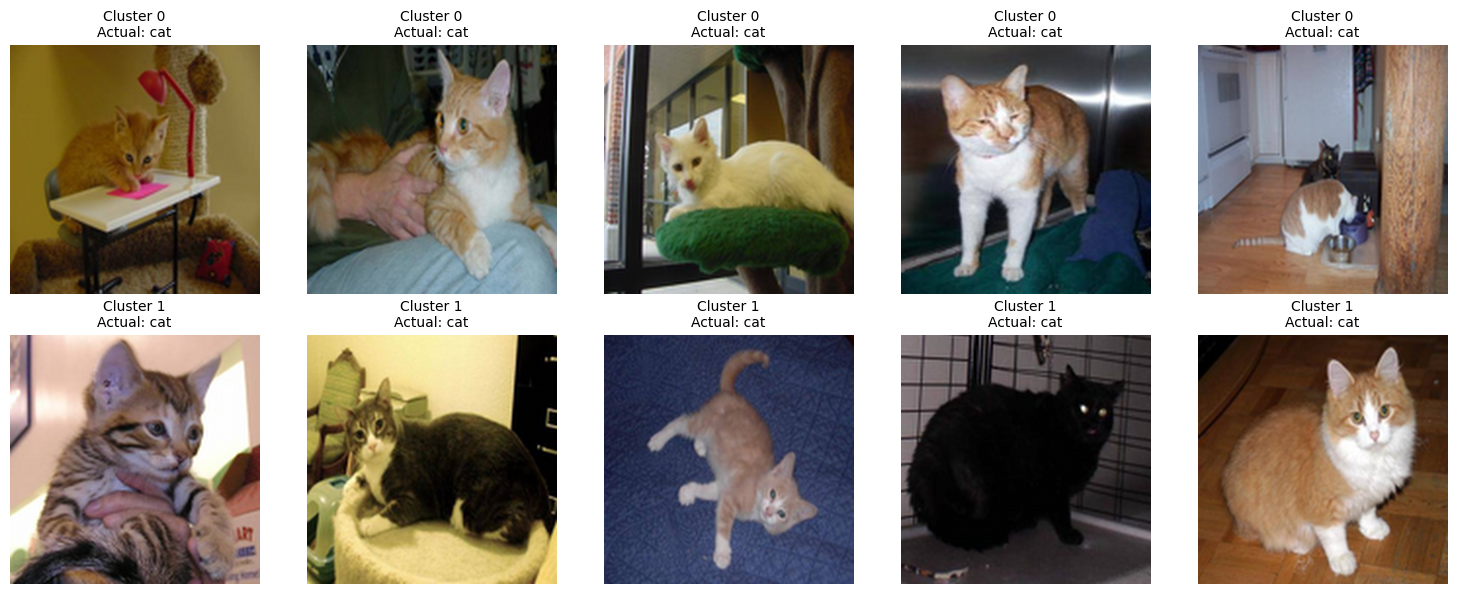

In [45]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Show first 5 images from each cluster
for cluster in range(2):
    
    indices = np.where(predicted_clusters == cluster)[0][:5]
    
    for j, index in enumerate(indices):
        ax = axes[cluster, j]
        
        ax.imshow(images[index], interpolation="lanczos")
        ax.set_title(
            f"Cluster {cluster}\nActual: {true_labels[index]}",
            fontsize=10
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import accuracy_score

# Find which cluster corresponds to which actual class
cluster_0_labels = [true_labels[i] for i in range(len(true_labels))
                    if predicted_clusters[i] == 0]

cluster_1_labels = [true_labels[i] for i in range(len(true_labels))
                    if predicted_clusters[i] == 1]

# Determine the most common label in each cluster
cluster_0_class = pd.Series(cluster_0_labels).mode()[0]
cluster_1_class = pd.Series(cluster_1_labels).mode()[0]

print("Cluster 0 =", cluster_0_class)
print("Cluster 1 =", cluster_1_class)

# Convert cluster numbers into predicted class labels
predicted_labels = []

for cluster in predicted_clusters:
    if cluster == 0:
        predicted_labels.append(cluster_0_class)
    else:
        predicted_labels.append(cluster_1_class)

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

print("\nAccuracy:", accuracy * 100, "%")

Cluster 0 = cat
Cluster 1 = dog

Accuracy: 57.49999999999999 %
